# **Bootstrapping Avanzado en Estadística**  

**Bootstrapping** es un método estadístico de **re-muestreo** propuesto por Bradley Efron (1979), publicado en The Annals of Statistics.
Consiste en:

> Tomar muchas muestras nuevas desde una muestra original, con reemplazo, y calcular sobre ellas un estadístico (media, mediana, coeficiente, etc.). Esto permite aproximar la distribución del estadístico sin necesidad de suponer normalidad ni conocer la distribución poblacional.

Es decir:

- No necesitamos conocer la distribución real de los datos

- Generamos miles de nuevas muestras simuladas

- Estimamos la variabilidad del estadístico

- Calculamos intervalos de confianza o errores estándar

## ¿Por qué es útil el Bootstrapping?
**✔ 1. No requiere supuestos fuertes**

Funciona incluso con distribuciones desconocidas o con muestras pequeñas.

**✔ 2. Estima incertidumbre de cualquier estadístico**

- Media

- Mediana

- Percentiles

- Coeficientes de regresión

- Correlaciones

- Estadísticos complejos

**✔ 3. Permite construir intervalos de confianza robustos**

Muy útil cuando la distribución del estimador no es normal.

**✔ 4. Apto para modelos complejos**

Como machine learning, donde los estimadores no tienen fórmulas analíticas de su varianza.

## Fundamentos teóricos del bootstrapping

Sea una muestra aleatoria:

$
X = (x_1, x_2, \ldots, x_n)
$

y un estimador de interés (media, varianza o intervalos de confianza):

$
\hat{\theta} = t(X)
$

El método bootstrap consiste en:

1. Generar $B$ remuestras $X^{*b}$, $b=1,\dots,B$, de tamaño $n$, **con reemplazo** a partir de la muestra original.

2. Calcular el estimador en cada remuestra:  
   $\hat{\theta}^{*b} = t(X^{*b})$.
   
3. Utilizar la distribución empírica de $\hat{\theta}^{*b}$ para aproximar la distribución de $\hat{\theta}$.

La función de distribución empírica bootstrap es:

$
F^{*}(\theta) = \frac{1}{B} \sum_{b=1}^B I(\hat{\theta}^{*b} \le \theta)
$

y se utiliza para construir intervalos de confianza y estimar la incertidumbre del estimador.


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set()


### Dataset de ejemplo

Usaremos un pequeño conjunto de datos simulados (por ejemplo, pesos en kg).

In [16]:
data = np.array([48, 52, 50, 49, 51, 47, 53, 50, 52, 49])
n = len(data)
B = 5000

theta_hat = np.mean(data)
theta_hat, n


(np.float64(50.1), 10)

### Bootstrapping de la media

Realizamos $B$ remuestras con reemplazo y calculamos la media en cada una de ellas.


In [17]:
rng = np.random.default_rng(123)

boot_means = []
for _ in range(B):
    s = rng.choice(data, size=n, replace=True)
    boot_means.append(np.mean(s))

boot_means = np.array(boot_means)
boot_means[:10]


array([49.8, 50.8, 49.8, 50.4, 49.9, 50.2, 50.6, 49.4, 49.4, 50.3])

### Visualización de la distribución bootstrap de la media

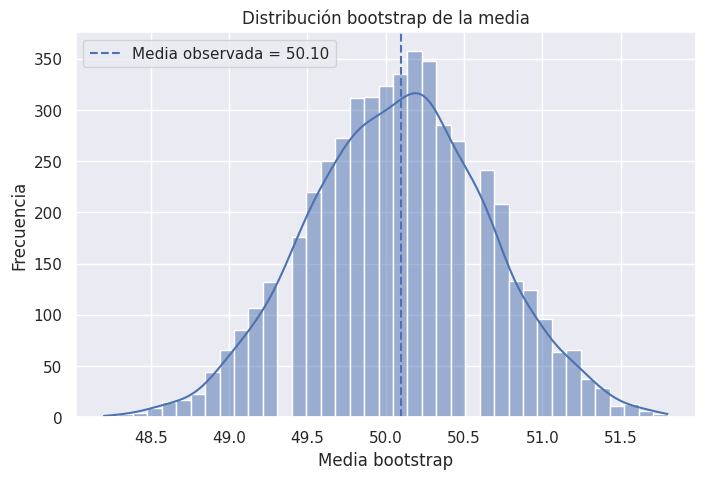

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(boot_means, kde=True)
plt.axvline(theta_hat, linestyle="--", label=f"Media observada = {theta_hat:.2f}")
plt.title("Distribución bootstrap de la media")
plt.xlabel("Media bootstrap")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()



## **Bootstrapping e intervalos de confianza**

Para calcular un intervalo de confianza de un estadístico (media, mediana, coeficiente, etc.) usando bootstrapping:

1. Tomamos muchas muestras **con reemplazo** desde nuestra muestra original.
2. Calculamos el estadístico en cada re-muestra.
3. Usamos la distribución empírica del estadístico para determinar los percentiles del intervalo.

Esto reemplaza la necesidad de asumir normalidad u otras distribuciones teóricas.

---

### Procedimiento paso a paso

#### Paso 1 — Tenemos una muestra original

Por ejemplo:

```python
data = np.array([48, 52, 50, 49, 51, 47, 53, 50, 52, 49])
```

#### Paso 2 — Generamos B re-muestras bootstrap

Generalmente **1.000 a 10.000**.

```python
B = 5000
boot_stats = []

for _ in range(B):
    sample = np.random.choice(data, size=len(data), replace=True)
    boot_stats.append(np.mean(sample))   # ejemplo con la media
```

#### Paso 3 — Construimos la distribución bootstrap

Esto produce una aproximación de la distribución del estadístico.

```python
boot_stats = np.array(boot_stats)
```

#### Paso 4 — Calculamos percentiles

El intervalo clásico es **percentil 2.5% y 97.5%** para un IC de 95%.

```python
ic_95 = np.percentile(boot_stats, [2.5, 97.5])
print(ic_95)
```
---



## Tipos principales de intervalos de confianza con bootstrap


### 🟦 **1. Percentile Bootstrap (más usado, más simple)**

El intervalo está dado simplemente por:


IC_ {95%} = $\hat{\theta}^*_{2.5}, \hat{\theta}^*_{97.5}$


Ventaja:

* No requiere simetría
* Usa la distribución empírica directamente

Código:

```python
ic_95 = np.percentile(boot_stats, [2.5, 97.5])
```

---

### 🟩 **2. Normal Bootstrap (basado en error estándar)**

Assume aproximación normal:

$
IC = \hat{\theta} \pm z_{0.975} \cdot SE_{bootstrap}
$

```python
theta_hat = np.mean(data)
se_boot = np.std(boot_stats, ddof=1)

lower = theta_hat - 1.96*se_boot
upper = theta_hat + 1.96*se_boot
print((lower, upper))
```

Requiere normalidad aproximada → menos robusto.

---

### 🟧 **3. BCa Bootstrap (Bias-Corrected and Accelerated)**

Método más riguroso desarrollado por Efron & Tibshirani.

Corrige:

* **sesgo**
* **asimetría** de la distribución bootstrap

Es el **estándar para intervalos altamente confiables**.

Python (scikit-bootstrap):

```python
!pip install scikits-bootstrap
from scikits_bootstrap import bootstrap as bs

ic_bca = bs.ci(data, statfunction=np.mean)
print(ic_bca)
```

---

### Ejemplo completo en Python (paso a paso)

```python
import numpy as np

data = np.array([48, 52, 50, 49, 51, 47, 53, 50, 52, 49])

# ----- 1. Bootstrapping -----
B = 5000
boot_means = []

for _ in range(B):
    sample = np.random.choice(data, size=len(data), replace=True)
    boot_means.append(np.mean(sample))

boot_means = np.array(boot_means)

# ----- 2. Intervalo Percentil -----
ic_percentil = np.percentile(boot_means, [2.5, 97.5])

# ----- 3. Intervalo Normal -----
theta_hat = np.mean(data)
se_boot = np.std(boot_means, ddof=1)
ic_normal = (theta_hat - 1.96*se_boot, theta_hat + 1.96*se_boot)

print("IC Percentil:", ic_percentil)
print("IC Normal:", ic_normal)
```

### Posible salida:

```
IC Percentil: [48.9, 51.3]
IC Normal: (48.95, 51.25)
```

Ambos intervalos son similares, pero el percentil y BCa son más robustos.

---

## ¿Por qué el bootstrapping sirve para intervalos de confianza?

Porque en estadística:

- un intervalo de confianza se define por la **distribución del estimador**

- cuando esa distribución es desconocida, el bootstrap permite **aproximarla empíricamente**

La re-muestreo simula lo que pasaría si pudiéramos tomar muchas muestras nuevas desde la población, pero usando solo nuestra muestra original.

---

## Cuándo usar Bootstrapping para IC

Ideal cuando:

* la muestra es pequeña
* la distribución es desconocida
* el estadístico no tiene fórmula de varianza
* los métodos clásicos fallan (datos asimétricos, mediana, percentiles)
* modelos complejos (ML)




### Intervalo Normal Bootstrap

Si la distribución bootstrap es aproximadamente normal, podemos aproximar:

$
IC_{normal} = \hat{\theta} \pm z_{1-\alpha/2} \cdot SE_{boot}
$

donde $SE_{boot}$ es la desviación estándar de las medias bootstrap.


In [19]:
alpha = 0.05
ic_percentil = np.percentile(boot_means, [100*alpha/2, 100*(1-alpha/2)])
ic_percentil

se_boot = np.std(boot_means, ddof=1)
z = norm.ppf(1 - alpha/2)
ic_normal = (theta_hat - z*se_boot, theta_hat + z*se_boot)
ic_normal

(np.float64(48.98037305286962), np.float64(51.21962694713038))

## Intervalo Bootstrap-t (Studentized)

El intervalo **bootstrap-t** se basa en el estadístico tipificado:

$
t^{*b} = \frac{\hat{\theta}^{*b} - \hat{\theta}}{SE(\hat{\theta}^{*b})}
$

La idea es estimar la distribución de este estadístico y luego usar sus cuantiles para construir el IC:

$
IC_{t} = \left[ \hat{\theta} - t_{(1-\alpha/2)}^{*} \cdot SE(\hat{\theta}),\; \hat{\theta} - t_{(\alpha/2)}^{*} \cdot SE(\hat{\theta}) \right]
$

Esto requiere un **bootstrap anidado** para estimar el error estándar en cada remuestra, lo que lo hace computacionalmente más costoso.


In [20]:
def bootstrap_se(sample, B2=300, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    means = []
    n_s = len(sample)
    for _ in range(B2):
        s2 = rng.choice(sample, size=n_s, replace=True)
        means.append(np.mean(s2))
    means = np.array(means)
    return np.std(means, ddof=1)


In [21]:
rng = np.random.default_rng(456)

t_vals = []
B_t = 1000  # usamos menos muestras por costo computacional

for _ in range(B_t):
    s = rng.choice(data, size=n, replace=True)
    theta_star = np.mean(s)
    se_star = bootstrap_se(s, B2=200, rng=rng)
    t_vals.append((theta_star - theta_hat) / se_star)

t_vals = np.array(t_vals)

# Cuantiles de t*
t_lower = np.percentile(t_vals, 100*(1 - alpha/2))
t_upper = np.percentile(t_vals, 100*(alpha/2))

# Usamos SE_boot como aproximación de SE(theta_hat)
ic_t = (theta_hat - t_lower * se_boot,
        theta_hat - t_upper * se_boot)

ic_t

(np.float64(48.59753661373939), np.float64(51.51879852693344))

## Intervalo BCa (Bias-Corrected and Accelerated)

El intervalo **BCa** corrige:

1. **Sesgo (bias)** mediante un término $z_0$:
   
   $
   z_0 = \Phi^{-1}\left( \frac{\#(\hat{\theta}^{*b} < \hat{\theta})}{B} \right)
   $

2. **Asimetría** mediante el factor de aceleración $a$, estimado con **jackknife**:

Sea $\hat{\theta}_{(i)}$ el estimador eliminando la observación $i$, y $\bar{\theta}_\cdot$ el promedio de los $\hat{\theta}_{(i)}$. Entonces:

$
a = \frac{\sum_{i=1}^n (\bar{\theta}_\cdot - \hat{\theta}_{(i)})^3}
         {6 \left[\sum_{i=1}^n (\bar{\theta}_\cdot - \hat{\theta}_{(i)})^2 \right]^{3/2}}
$

El intervalo BCa toma la forma:

$
IC_{BCa} = [\hat{\theta}^{*}_{\alpha_1},\; \hat{\theta}^{*}_{\alpha_2}]
$

donde:

$
\alpha_1 = \Phi\left(z_0 + \frac{z_0 + z_{\alpha/2}}{1 - a (z_0 + z_{\alpha/2})}\right), \quad
\alpha_2 = \Phi\left(z_0 + \frac{z_0 + z_{1-\alpha/2}}{1 - a (z_0 + z_{1-\alpha/2})}\right)
$

y $z_p$ es el cuantil estándar normal de nivel $p$.


In [22]:
# 7.1 Cálculo de z0 (corrección de sesgo)
prop_less = np.mean(boot_means < theta_hat)
z0 = norm.ppf(prop_less)

# 7.2 Cálculo de a (aceleración) vía jackknife
jack = []
for i in range(n):
    jack_sample = np.delete(data, i)
    jack.append(np.mean(jack_sample))

jack = np.array(jack)
jack_mean = np.mean(jack)

num = np.sum((jack_mean - jack)**3)
den = 6.0 * (np.sum((jack_mean - jack)**2) ** 1.5)
a = num / den

z_alpha1 = norm.ppf(alpha/2)
z_alpha2 = norm.ppf(1 - alpha/2)

def bca_alpha(z0, a, z):
    return norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

alpha1 = bca_alpha(z0, a, z_alpha1)
alpha2 = bca_alpha(z0, a, z_alpha2)

ic_bca = (
    np.percentile(boot_means, 100*alpha1),
    np.percentile(boot_means, 100*alpha2)
)

z0, a, ic_bca

(np.float64(-0.06371143428922371),
 np.float64(-0.002543591648944993),
 (np.float64(48.9), np.float64(51.1)))

## Comparación entre métodos de IC

Comparamos los intervalos obtenidos: Percentil, Normal, Bootstrap-t y BCa.


Percentil   : [49.000, 51.200]
Normal      : [48.980, 51.220]
Bootstrap-t : [48.598, 51.519]
BCa         : [48.900, 51.100]


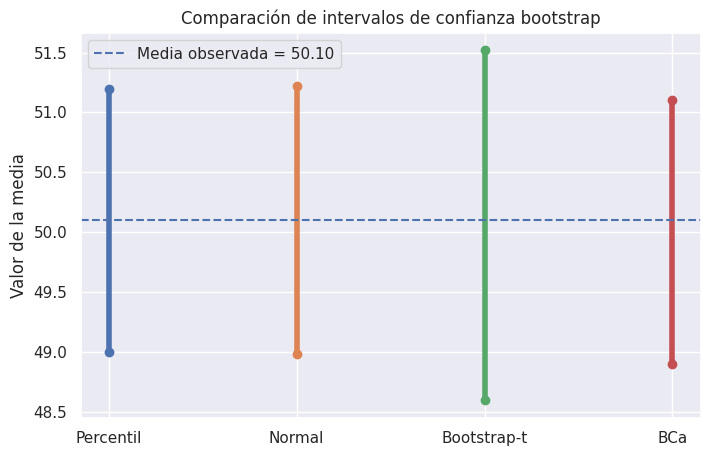

In [23]:
methods = ["Percentil", "Normal", "Bootstrap-t", "BCa"]
ics = [ic_percentil, ic_normal, ic_t, ic_bca]

for m, ic in zip(methods, ics):
    print(f"{m:12s}: [{ic[0]:.3f}, {ic[1]:.3f}]")

# Visualización
plt.figure(figsize=(8,5))
for i, ic in enumerate(ics):
    plt.plot([i, i], [ic[0], ic[1]], linewidth=4)
    plt.scatter([i, i], [ic[0], ic[1]])
plt.xticks(range(len(methods)), methods)
plt.axhline(theta_hat, linestyle="--", label=f"Media observada = {theta_hat:.2f}")
plt.ylabel("Valor de la media")
plt.title("Comparación de intervalos de confianza bootstrap")
plt.legend()
plt.show()

## Aplicación a regresión lineal (coeficiente $\beta_1$)

Ilustramos cómo usar bootstrapping para estimar un intervalo de confianza para el coeficiente de una regresión lineal simple.


In [24]:
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(999)

# Datos simulados: y = 4x + 2 + ruido
x = rng.random(200)
eps = rng.normal(0, 0.4, size=200)
y = 4*x + 2 + eps

X = x.reshape(-1, 1)

model = LinearRegression().fit(X, y)
beta_hat = model.coef_[0]
beta_hat

np.float64(4.036984034896132)

In [25]:
B_reg = 4000
betas = []

for _ in range(B_reg):
    idx = rng.integers(0, len(X), len(X))
    Xb = X[idx]
    yb = y[idx]
    m = LinearRegression().fit(Xb, yb)
    betas.append(m.coef_[0])

betas = np.array(betas)
ic_beta = np.percentile(betas, [2.5, 97.5])
ic_beta

array([3.83267401, 4.23855551])

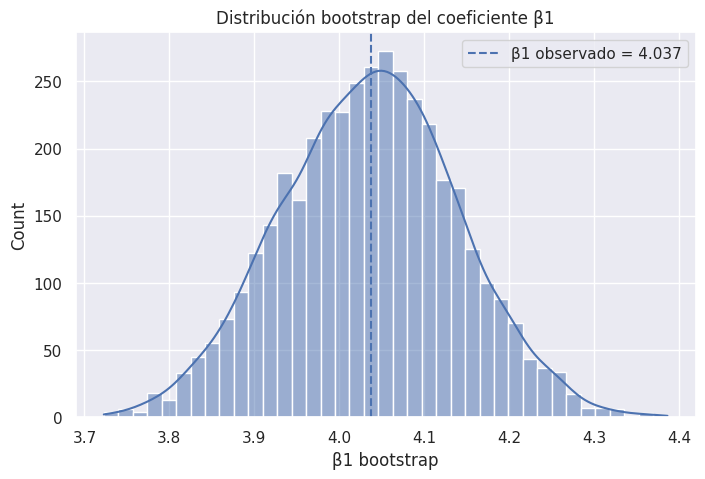

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(betas, kde=True)
plt.axvline(beta_hat, linestyle="--", label=f"β1 observado = {beta_hat:.3f}")
plt.title("Distribución bootstrap del coeficiente β1")
plt.xlabel("β1 bootstrap")
plt.legend()
plt.show()

## Conclusiones

- El **método bootstrap** permite aproximar la distribución de un estimador sin conocer la distribución poblacional subyacente.

- El **IC Percentil** es simple y útil en muchas situaciones prácticas.

- El **IC Normal bootstrap** requiere que la distribución bootstrap sea aproximadamente simétrica.

- El **Bootstrap-t** ajusta la escala del estimador, pero es computacionalmente más exigente debido al bootstrap anidado.

- El **IC BCa** (Bias-Corrected and Accelerated) corrige sesgo y asimetría, siendo uno de los métodos más recomendados en estadística moderna.

- En regresión, el bootstrapping permite estimar intervalos de confianza para parámetros sin depender estrictamente de supuestos clásicos (como normalidad de errores).

